In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from classification_training_reporter import TrainingReporter
from models.classification_rf_model import build_model_from_grid_params
from classification_dataset_preprocessing import make_label_pipeline, make_standarize_pipeline
from models.classification_rf_model import CustomRandomForestModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Odczyt datasetu

In [2]:
df = pd.read_csv(os.path.join("../data", "ortodoncja.csv"))

# Podział danych na zbiór treningowy i testowy

In [3]:
# pipeline = make_label_pipeline()
# df_processed = pipeline.fit_transform(df)
# label_encoder = pipeline.named_steps["encode_labels"].encoder
#
# X = df_processed.drop(columns=["growth direction"])
# y = df_processed["growth direction"]
#
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#
# tpipeline = make_training_pipeline()
# X_train, y_train = tpipeline.fit_resample(X_train,y_train)
# X_test = tpipeline[:1].fit_transform(X_test)

pipeline = make_label_pipeline()
df_processed = pipeline.fit_transform(df)
label_encoder = pipeline.named_steps["encode_labels"].encoder

X = df_processed.drop(columns=["growth direction"])
y = df_processed["growth direction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

spipeline = make_standarize_pipeline()
X_train = spipeline.fit_transform(X_train)
X_test = spipeline.fit_transform(X_test)

# Inicjalizacja reportera do treningów

In [4]:
model = CustomRandomForestModel()
reporter = TrainingReporter(model, X_train, X_test, y_train, y_test)

# Pierwszy trening

In [5]:
reporter.train()

Start training...
Training finished!
Train Accuracy: 0.9270  |  Test Accuracy: 0.7667
Train F1:       0.9271  |  Test F1:       0.7527
Train AUROC:    0.9836  |  Test AUROC:    0.8558
---------------------------------------------------


# Cross walidacja

In [6]:
reporter.run_cross_validation(cv=10)

Start cross validation...
Fold 0:
  Train Accuracy: 0.9219  |  Val Accuracy: 0.7500
  Train F1:       0.9220  |  Val F1:       0.7399
---------------------------------------------------
Fold 1:
  Train Accuracy: 0.9375  |  Val Accuracy: 0.8056
  Train F1:       0.9376  |  Val F1:       0.8055
---------------------------------------------------
Fold 2:
  Train Accuracy: 0.9250  |  Val Accuracy: 0.8333
  Train F1:       0.9251  |  Val F1:       0.8193
---------------------------------------------------
Fold 3:
  Train Accuracy: 0.9250  |  Val Accuracy: 0.8056
  Train F1:       0.9252  |  Val F1:       0.7940
---------------------------------------------------
Fold 4:
  Train Accuracy: 0.9375  |  Val Accuracy: 0.8333
  Train F1:       0.9377  |  Val F1:       0.8333
---------------------------------------------------
Fold 5:
  Train Accuracy: 0.9406  |  Val Accuracy: 0.6667
  Train F1:       0.9407  |  Val F1:       0.6440
---------------------------------------------------
Fold 6:
  Trai

# Randomized grid search

In [7]:
random_grid = reporter.run_randomized_search_rf(cv=5)

Start randomized grid search for Random Forest...
Randomized search finished!
Best params: {'n_estimators': np.int64(900), 'min_samples_split': np.int64(3), 'min_samples_leaf': np.int64(6), 'max_features': 0.5, 'max_depth': 7}
Best F1 score: 0.8134370797787863
---------------------------------------------------


# Kroswalidacja po dostosowaniu hiperparametrów za pomocą Randomized Grid Search

In [8]:
model_RGS = build_model_from_grid_params(random_grid.best_params_)
reporter_RGS = TrainingReporter(model_RGS, X_train, X_test, y_train, y_test)
reporter_RGS.run_cross_validation(cv=10)

Start cross validation...
Fold 0:
  Train Accuracy: 0.8875  |  Val Accuracy: 0.7222
  Train F1:       0.8888  |  Val F1:       0.7124
---------------------------------------------------
Fold 1:
  Train Accuracy: 0.9000  |  Val Accuracy: 0.8333
  Train F1:       0.9005  |  Val F1:       0.8433
---------------------------------------------------
Fold 2:
  Train Accuracy: 0.8938  |  Val Accuracy: 0.8611
  Train F1:       0.8951  |  Val F1:       0.8464
---------------------------------------------------
Fold 3:
  Train Accuracy: 0.8938  |  Val Accuracy: 0.7778
  Train F1:       0.8947  |  Val F1:       0.7670
---------------------------------------------------
Fold 4:
  Train Accuracy: 0.8938  |  Val Accuracy: 0.8333
  Train F1:       0.8950  |  Val F1:       0.8333
---------------------------------------------------
Fold 5:
  Train Accuracy: 0.9000  |  Val Accuracy: 0.7778
  Train F1:       0.9014  |  Val F1:       0.7751
---------------------------------------------------
Fold 6:
  Trai

## Podejrzenie overfittingu i niestabilność kroswalidacji

# Test

In [9]:
model = reporter_RGS.model
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

## Metryki

In [10]:
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted')
test_recall = recall_score(y_test, y_pred_test, average=None)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
cm = confusion_matrix(y_test, y_pred_test)
class_names = label_encoder.inverse_transform(range(len(label_encoder.classes_)))

## Statystyki

In [11]:
print("\n" + "="*50)
print("TEST RESULTS")
print("="*50)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")
print("Test Recall:")
for i, recall in enumerate(test_recall):
    print(f"{class_names[i]}: {recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))


TEST RESULTS
Test Accuracy:  0.7556
Test Precision: 0.7496
Test F1 Score:  0.7514
Test Recall:
horizontal: 0.7778
normal: 0.7917
vertical: 0.3333

Detailed Classification Report:
              precision    recall  f1-score   support

  horizontal       0.76      0.78      0.77        36
      normal       0.78      0.79      0.78        48
    vertical       0.50      0.33      0.40         6

    accuracy                           0.76        90
   macro avg       0.68      0.63      0.65        90
weighted avg       0.75      0.76      0.75        90



## Confusion matrix

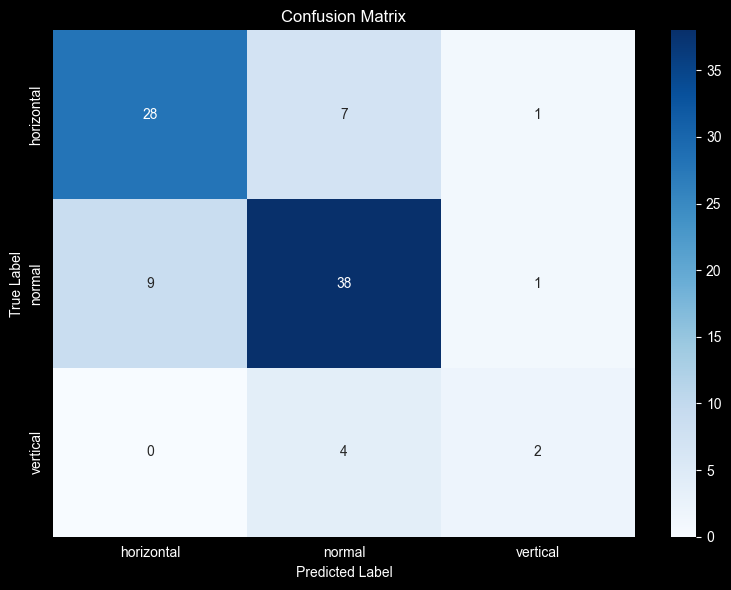

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Porónwanie kroswalidacji i testu

In [13]:
cv_f1 = random_grid.best_score_
print("\n" + "="*50)
print("CV vs TEST COMPARISON")
print("="*50)
print(f"CV F1 score:    {cv_f1:.4f}")
print(f"Test F1 score:  {test_f1:.4f}")
print(f"Gap:            {(cv_f1 - test_f1):.4f}")


CV vs TEST COMPARISON
CV F1 score:    0.8134
Test F1 score:  0.7514
Gap:            0.0621


# Taki średni